# Visualizing Truss Mesh

In this chapter, we shall get familiar with the visualization of the above truss stucture and thereby learn how to work with these data sets which are very common in Finite Element Analysis (FEA) settings.

The treatment of these data sets introduced here are transferable to other types of meshes and fields. By visualization code we get familiar with the data sets as well as typical visualization patterns for FEA data.

### The Why

We will be using what we learn here in many future courses: mechanics, solid mechanics, mechatronics, mechanical engineering design, Finite Element Method, etc. In these course, we will be implementing algorithms and creating models to solve relevant, real-world problems. 

Visualization is a good way of *verifying results* in general problem solving. 

::: {.callout-important}
Remember that in engineering, there are no right answer sheets! Instead, we need to practice verification and validation of results. 
:::

*Verification* is a process of checking if the methods applied are *applied correctly*. We ask the question: Do we get the results we expect? We can do verification by setting up a problem with known solution or a trivial solution and do thought experiments. Part of a verification process is checking if a result is *reasonable*. We systematically ask questions to our models, get results and *contemplate the consequences* of these results.

*Validation*, on the other hand, is a process of checking if the methods are applicable to the problem at hand. Is the model in it self correctly modeling the physics of the problem? This needs to be done by comparing simulation results with experimental data, gathered by conducting physical experiments.


## Visualization of Truss

Consider the example truss shown below:

![Example truss](graphics/SystematicTrussAnalysis-2.png){fig-align="center" width=20em #fig-truss}

With the data provided by the typical data set:

```default
P:
0,   0     # Node 1
500, 0     # Node 2
300, 300   # Node 3
600, 300   # Node 4


elements: 
1, 2   # Element 1 connects nodes 1 and 2
1, 3   # Element 2 connects nodes 1 and 3
2, 3   # Element 3 connects nodes 2 and 3
2, 4   # Element 4 connects nodes 2 and 4
3, 4   # Element 5 connects nodes 3 and 4

Displacement vector u (in mm)
Format: [u1x, u1y, u2x, u2y, u3x, u3y, u4x, u4y]

u: [0, 0, -0.1984127, 0, 0.24666587, 0.09005164, 0.44507857, -0.91164825]

It is implied that the displacements in node 1 are zero in both x and y direction 
and that the displacements in node 2 are zero in y direction.

# Element forces N (in N)
# Positive = tension, Negative = compression
N: [16800,  20000, -22360, 0]

# Reaction forces (in N)
# Format: [R1x, R1y, R2x, R2y, R3x, R3y, R4x, R4y]
R: [3200,  10000,  16800,  0, 0, -10000, -20000,  0]

# External forces (in N)
# Format: [Fx1, Fy1]
F = [0, -10000.0] # Acting at node 4
```

### The How

Our visualization pipeline will proceed through several stages, each adressing different aspects of what is interesting to visualize for a truss problem. 

- We begin by rendering the undeformed geometry from @fig-truss, drawing element lines with their connectivity and labeling both nodes and elements at appropriate positions. - After establishing the baseline geometry, we display the deformed configuration using the displacement vector $u$, scaling the deformations for visibility.
- To visualize internal element forces $N$, we employ color coding that distinguishes tension (red) from compression (blue), immediately revealing which members resist pulling versus pushing.
- Once we have the deformed geometry, we color-code the members based on nodal displacement magnitudes through linear interpolation along each element.
- We incorporate the loading conditions by rendering the applied force $F$ as a vector arrow at node 4, showing both magnitude and direction. 
- The support reactions $R$ receive similar treatment, with arrows indicating how the structure transfers loads to its boundary constraints.  

## Implementing FEM mesh algorithms in Python: The Array Indexing Problem

A mesh is a data structure that represents a geometric shape. The nodal coordinates are given by the vertices of the mesh, and the element connectivity is given by the edges of the mesh. The connectivity matrix `elements` is a matrix of size `N x 2`, where `N` is the number of elements. The coordinate (or nodes) matrix `P` is a matrix of size `M x 2`, where `M` is the number of nodes. This is in 2D, but it can be extended to 3D by an additional column for the z-coordinate. The first column of `elements` is the node number of the first node of the element, and the second column is the node number of the second node of the element. If we want, for example, the nodes of the first element, we need to access the first row of `elements` to grab the nodal numbers `1, 2` for the first element. These indices are then used to access the nodal coordinates from the `P` matrix. Notice here, in this description, we use natural language to say "first" element, "second" column, etc. This is because in a FEM setting, the mesh is typically 1-indexed. This goes beyond this simple example, in commercial FEM software, the mesh data is given 1-indexed and has typically an additional column for numbering the nodes and elements since we can have a blend of different element types and parts. The problem is if we now want to work with this data in python, we need to use 0-indexing and keep a mental map between the natural 1-indexed and 0-indexed data. This yields a lot of -1 offsets as well as +1 offsets spread throughout the code to compansate for this. For beginners, this can be a source of confusion and errors. It hinders learning and adds an artificial complexity to the code. 

## The Solution: MechanicsKit - A simple wrapper for 1-based indexing using Python

The fix is not to abandon Python for MATLAB (or Julia), nor to abandon mathematical notation for 0-based thinking. The fix is to create a thin abstraction layer that handles the indexing translation automatically, allowing us to write Python code that reads like mathematical notation. This is precisely what MechanicsKit provides.

MechanicsKit introduces two key components:

1. **`Mesh` class**: Handles node and element access with 1-based numbering while storing data efficiently as 0-based NumPy arrays internally.
2. **`OneArray` class**: Wraps result arrays (element forces, nodal temperatures, etc.) to provide 1-based access.

We demonstrate this by implementing our truss visualization using MechanicsKit.

### Installing MechanicsKit

We begin by loading the necessary libraries, we have a helper library `MechanicsKit` that contains functions for one-indexing mesh data for further processing and visualization.

The library can be found [here](https://github.com/cenmir/MechanicsKit).

Install it using

```bash
uv pip install git+https://github.com/cenmir/MechanicsKit.git
```

Then we can include the helper functions by

In [1]:
# | code-fold: false

import numpy as np
import matplotlib.pyplot as plt
import mechanicskit as mk

# For nice plots
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

### Understanding the mechanicskit.Mesh Class

We start by creating a mesh object and inspecting its basic properties:

In [2]:
# | code-fold: false

# Node coordinates - same as before
P = np.array([[0, 0],
              [500, 0],
              [300, 300],
              [600, 300]])

# Element connectivity - using natural 1-based node numbers
edges = np.array([[1, 2],
                  [1, 3],
                  [2, 3],
                  [2, 4],
                  [3, 4]])

# Create mesh (auto-detects ROD elements from 2 nodes per element)
mesh = mk.Mesh(P, edges)

After creating a mesh, we can inspect its basic properties directly:

In [3]:
# | code-fold: false
print("Number of nodes in the mesh: ", mesh.n_nodes)
print("Number of elements: ", mesh.n_elements)
print("Spatial dimension: ", mesh.n_dim)
print("Element type: ", mesh.element_type)
print("Degrees of freedom per node: ", mesh.dofs_per_node)
print("Total degrees of freedom: ", mesh.n_dofs)

Number of nodes in the mesh:  4
Number of elements:  5
Spatial dimension:  2
Element type:  ROD
Degrees of freedom per node:  2
Total degrees of freedom:  8


For a comprehensive overview of the mesh structure, we can use the `summary()` method, which displays node coordinates and element connectivity using 1-based numbering:

In [4]:
# | code-fold: false
mesh.summary()

Mesh Summary
Element type:       ROD - 1D rod/truss element
Number of nodes:    4
Number of elements: 5
Dimension:          2D
DOFs per node:      2
Total DOFs:         8

Node Coordinates (1-based numbering):
------------------------------------------------------------
  Node 1: [0. 0.]
  Node 2: [500.   0.]
  Node 3: [300. 300.]
  Node 4: [600. 300.]

Element Connectivity (1-based numbering):
------------------------------------------------------------
  Element 1: Nodes [np.int64(1), np.int64(2)]
  Element 2: Nodes [np.int64(1), np.int64(3)]
  Element 3: Nodes [np.int64(2), np.int64(3)]
  Element 4: Nodes [np.int64(2), np.int64(4)]
  Element 5: Nodes [np.int64(3), np.int64(4)]


#### Accessing Mesh Data

The mesh provides several methods for retrieving geometric and connectivity information. All methods use 1-based indexing for nodes and elements, matching the mathematical notation in finite element theory. The key access methods are:

| Method | Description | Example |
|--------|-------------|---------|
| `mesh.get_node(i)` | Returns coordinates of node $i$ | `coords = mesh.get_node(3)` |
| `mesh.get_element(e)` | Returns node numbers and coordinates for element $e$ | `nodes, coords = mesh.get_element(1)` |
| `mesh.dofs_for_node(i)` | Returns DOF indices for node $i$ (0-based for array indexing) | `dofs = mesh.dofs_for_node(3)` |
| `mesh.dofs_for_element(e)` | Returns all DOF indices for element $e$ | `dofs = mesh.dofs_for_element(1)` |
| `mesh.node_for_dof(j)` | Returns node number for DOF index $j$ (inverse operation) | `node = mesh.node_for_dof(4)` |
| `mesh.iter_nodes()`    | Generator for iterating over all nodes | `for inod, coords in mesh.iter_nodes(): ...` |
| `mesh.iter_elements()` | Generator for iterating over all elements | `for iel, inods, coords in mesh.iter_elements(): ...` |

These methods accept either single integers or lists of integers, returning appropriately shaped arrays. When we request `mesh.get_node([1, 3, 5])`, the method returns a $(3 \times d)$ array containing coordinates for nodes 1, 3, and 5, where $d$ is the spatial dimension.

## Visualizing a Truss Mesh


Here we have the complete code for a truss visualization using MechanicsKit. After this we will break it down into smaller parts and explain each one.

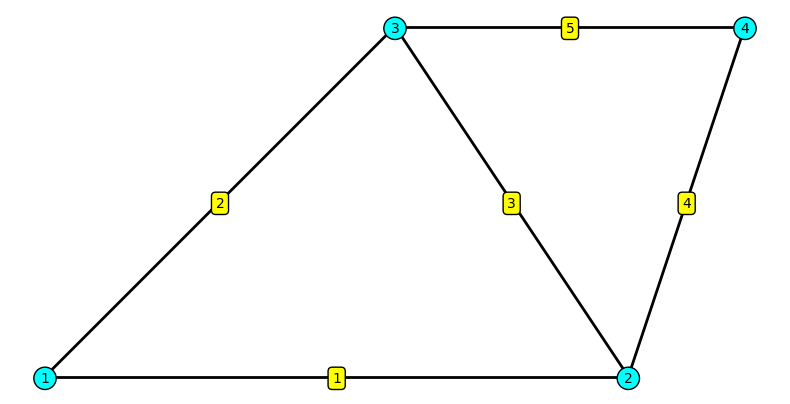

In [5]:
# Node coordinates - same as before
P = np.array([[0, 0],
              [500, 0],
              [300, 300],
              [600, 300]])

# Element connectivity - using natural 1-based node numbers
edges = np.array([[1, 2],
                  [1, 3],
                  [2, 3],
                  [2, 4],
                  [3, 4]])

# Create mesh (auto-detects ROD elements from 2 nodes per element)
mesh = mk.Mesh(P, edges)

# Visualization with MechanicsKit
fig, ax = plt.subplots(figsize=(8, 6))

# Draw elements using natural iteration
for iel in mesh.element_numbers():  # Yields 1, 2, 3, 4, 5
    node_nums, coords = mesh.get_element(iel)  # Natural 1-based access!
    ax.plot(coords[:, 0], coords[:, 1], 'k-', linewidth=2)

# Draw nodes
# ax.plot(P[:, 0], P[:, 1], 'o', color='cyan',
#         markeredgecolor='black', markersize=14)

# Label nodes
for inode in mesh.node_numbers():  # Yields 1, 2, 3, 4
    coord = mesh.get_node(inode)  # Natural 1-based access!
    # ax.text(coord[0] - 20, coord[1], str(inode),
    #         fontsize=12, ha='right')
    ax.text(coord[0], coord[1]-5, str(inode),  # Must add 1 for label!
            bbox=dict(boxstyle='circle', facecolor='cyan'),
            fontsize=10, ha='center')

# Label elements  
for iel in mesh.element_numbers():
    node_nums, coords = mesh.get_element(iel)
    xm = np.mean(coords[:, 0])
    ym = np.mean(coords[:, 1])
    ax.text(xm, ym-5, str(iel),
            bbox=dict(boxstyle='round', facecolor='yellow'),
            fontsize=10, ha='center')

ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()

### Code Explanation

This code creates a visualization of a finite element truss structure. Here's a breakdown of each section:



#### 1. Data Setup

```python
P = np.array([[0, 0],
              [500, 0],
              [300, 300],
              [600, 300]])
```
- **`P`**: Node coordinates matrix - defines the (x, y) positions of the 4 nodes in millimeters
- Node 1: (0, 0), Node 2: (500, 0), Node 3: (300, 300), Node 4: (600, 300)

```python
edges = np.array([[1, 2],
                  [1, 3],
                  [2, 3],
                  [2, 4],
                  [3, 4]])
```
- **`edges`**: Element connectivity matrix - defines which nodes are connected by each element
- Uses **1-based indexing** (natural numbering) instead of Python's 0-based indexing
- Element 1 connects nodes 1-2, Element 2 connects nodes 1-3, etc.


#### 2. Mesh Creation

```python
mesh = mk.Mesh(P, edges)
```
- Creates a `Mesh` object from the MechanicsKit library
- Automatically detects ROD elements (2 nodes per element)
- Handles the conversion between 1-based and 0-based indexing internally

#### 3. Drawing Elements

```python
for iel in mesh.element_numbers():  # Yields 1, 2, 3, 4, 5
    node_nums, coords = mesh.get_element(iel)
    ax.plot(coords[:, 0], coords[:, 1], 'k-', linewidth=2)
```
- Iterates through elements using **natural 1-based numbering** (1, 2, 3, 4, 5)
- `mesh.get_element(iel)` returns the node numbers and coordinates for element `iel`
- Draws each element as a black line (`'k-'`) with thickness 2


#### 4. Labeling Nodes

```python
for inode in mesh.node_numbers():  # Yields 1, 2, 3, 4
    coord = mesh.get_node(inode)
    ax.text(coord[0], coord[1]-5, str(inode),
            bbox=dict(boxstyle='circle', facecolor='cyan'),
            fontsize=10, ha='center')
```
- Iterates through nodes using **natural 1-based numbering** (1, 2, 3, 4)
- `mesh.get_node(inode)` retrieves the coordinates for node `inode`
- Places text label at position `(x, y-5)` - slightly below the node
- **`bbox`**: Creates a circular background box
  - `boxstyle='circle'`: Makes the box circular
  - `facecolor='cyan'`: Cyan background color
- `ha='center'`: Horizontally centers the text


#### 5. Labeling Elements

```python
for iel in mesh.element_numbers():
    node_nums, coords = mesh.get_element(iel)
    xm = np.mean(coords[:, 0])  # Mean x-coordinate
    ym = np.mean(coords[:, 1])  # Mean y-coordinate
    ax.text(xm, ym-5, str(iel),
            bbox=dict(boxstyle='round', facecolor='yellow'),
            fontsize=10, ha='center')
```
- Calculates the midpoint of each element by averaging the node coordinates
- Places the element number at the midpoint
- **`bbox`**: Creates a rounded rectangular background
  - `boxstyle='round'`: Rounded corners (can be changed to `'circle'` for circular boxes)
  - `facecolor='yellow'`: Yellow background color


#### 6. Final Formatting

```python
ax.set_aspect('equal')  # Equal scaling for x and y axes
ax.axis('off')          # Hide axes
plt.tight_layout()      # Optimize spacing
plt.show()              # Display the figure
```



## Visualizing the deformed truss

### Understanding Displacement Data

In finite element analysis, nodal displacements are typically stored in a **1D vector** where the x and y components alternate:

```
u = [u1x, u1y, u2x, u2y, u3x, u3y, u4x, u4y]
```

For our truss example with 4 nodes, the displacement vector from FEM analysis is:

In [6]:
# | echo: false
from mechanicskit import display_labeled_latex


In [7]:
# | code-fold: false
# Displacement vector u (in mm)
# Format: [u1x, u1y, u2x, u2y, u3x, u3y, u4x, u4y]
u = np.array([[0, 0, -0.1984, 0, 0.2466, 0.0900, 0.4450, -0.9116]])

In [8]:
# | echo: false
display_labeled_latex("\\mathbf{{u}} = ", u,4)

<IPython.core.display.Latex object>

### Reshaping Displacements into a Matrix

For visualization, it's more convenient to organize the displacements as a **matrix** where:

- Each row represents one node
- Column 1 contains x-displacements  
- Column 2 contains y-displacements

```default
U = [[u1x, u1y],    ← Node 1 displacements
     [u2x, u2y],    ← Node 2 displacements
     [u3x, u3y],    ← Node 3 displacements
     [u4x, u4y]]    ← Node 4 displacements
```

We use NumPy's `reshape()` function to reorganize the 1D vector into this 2D matrix:

In [9]:
# | code-fold: false
# Reshape from 1D to 2D matrix (4 nodes × 2 components)
U = u.reshape(-1, 2)  # -1 means "figure out the number of rows automatically"

In [10]:
# | echo: false
display_labeled_latex("\\mathbf{{U}} = ", U, precision=4, show_shape=True)

<IPython.core.display.Latex object>

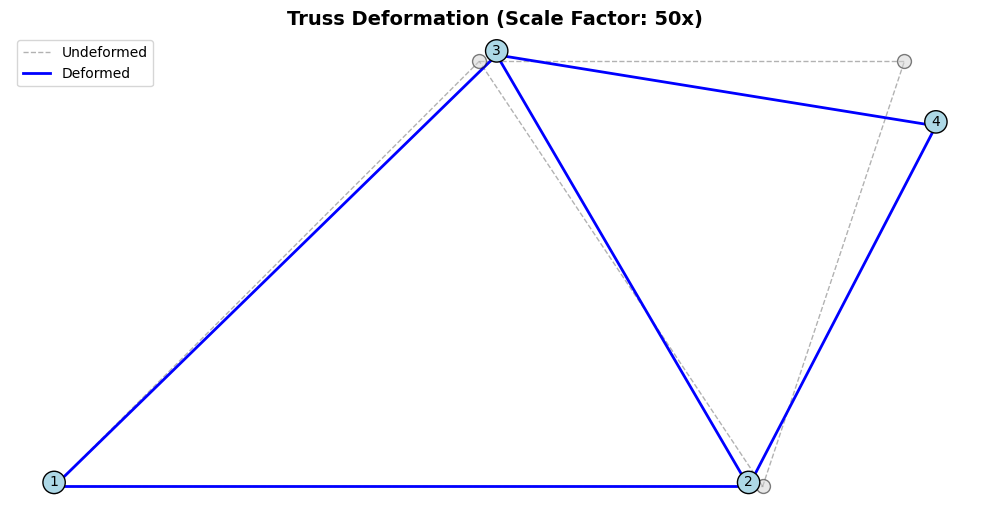

In [11]:
# | code-fold: true
# Scale factor for visualization (to exaggerate deformations)
scale = 50

# Calculate deformed node positions using OneArray for natural 1-based indexing
P_deformed = mk.OneArray(P + scale * U)

# Create figure
fig, ax = plt.subplots(figsize=(10, 7))

# Draw original (undeformed) truss in gray
for iel in mesh.element_numbers():
    node_nums, coords = mesh.get_element(iel)
    ax.plot(coords[:, 0], coords[:, 1], 'k--', linewidth=1, alpha=0.3, 
            label='Undeformed' if iel == 1 else '')

# Draw deformed truss in blue
for iel in mesh.element_numbers():
    node_nums, coords = mesh.get_element(iel)
    coords_deformed = P_deformed[node_nums]  # Natural 1-based indexing!
    ax.plot(coords_deformed[:, 0], coords_deformed[:, 1], 'b-', linewidth=2, 
            label='Deformed' if iel == 1 else '')

# Draw original nodes
ax.plot(P[:, 0], P[:, 1], 'o', color='lightgray', 
        markeredgecolor='black', markersize=10, alpha=0.5)

# Label deformed nodes
for inode in mesh.node_numbers():
    coord_deformed = P_deformed[inode]  # Natural 1-based indexing!
    ax.text(coord_deformed[0], coord_deformed[1], str(inode),
            bbox=dict(boxstyle='circle', facecolor='lightblue'),
            fontsize=10, ha='center')

# Add title and legend
ax.set_title(f'Truss Deformation (Scale Factor: {scale}x)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()

## Interpolated nodal colors

## Visualizing Displacement Magnitude with Interpolated Colors

Having visualized the deformed geometry, let's color-code each truss member according to the displacement magnitude at the nodes. The displacement magnitude at each node combines both x and y components through the Euclidean norm $|\mathbf{u}| = \sqrt{u_x^2 + u_y^2}$, providing a scalar measure of how far each node moves from its original position. Since truss elements assume linear variation of displacement along their length, we interpolate the displacement magnitude linearly between the two end nodes to create a smooth color gradient along each member. This visualization immediately reveals which regions of the structure experience the largest displacements and how the displacement field varies spatially.

In [12]:
# | code-fold: false

# Compute resultant displacement magnitudes at each node
U_res = np.sqrt(U[:, 0]**2 + U[:, 1]**2)

# Wrap in OneArray for 1-based indexing
U_res_1based = mk.OneArray(U_res)

We compute the displacement magnitude vector $\mathbf{U}_{\text{res}}$, where each component represents the Euclidean norm of the displacement at the corresponding node:

The visualization again uses `LineCollection` for straightforward color mapping. By dividing each element into 100 sub-segments and computing interpolated displacement magnitudes at their midpoints, we create smooth color gradients without manually managing colormap normalization—the collection handles this automatically when we pass the `array` of displacement values.

In [13]:
# | echo: false
display_labeled_latex("\\mathbf{U}_{\\text{res}} = ", U_res_1based, precision=4, show_shape=True)

<IPython.core.display.Latex object>

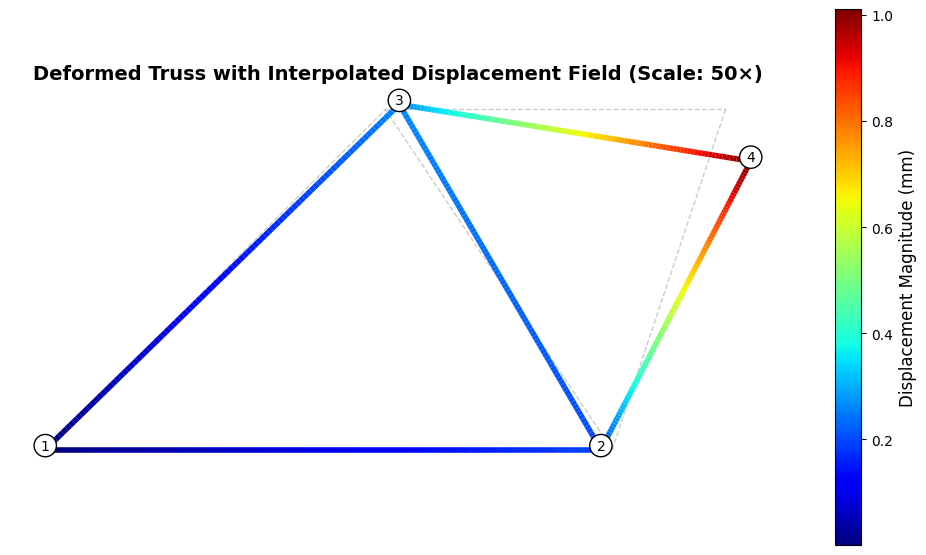

In [14]:
# | code-fold: true

from matplotlib.collections import LineCollection

# Scale factor for visualization
scale = 50

# Calculate deformed node positions
P_deformed = mk.OneArray(P + scale * U)

# Create figure
fig, ax = plt.subplots(figsize=(10, 7))

# Draw original (undeformed) truss in gray for reference
for iel in mesh.element_numbers():
    node_nums, coords = mesh.get_element(iel)
    ax.plot(coords[:, 0], coords[:, 1], 'k--', linewidth=1, alpha=0.2)

# Create interpolated segments for smooth color transitions
segments = []
segment_colors = []

n_segments = 100  # Number of segments per element for smooth gradients

for iel in mesh.element_numbers():
    node_nums, coords = mesh.get_element(iel)
    coords_deformed = P_deformed[node_nums]
    
    # Get displacement magnitudes at element nodes
    u1 = U_res_1based[node_nums[0]]
    u2 = U_res_1based[node_nums[1]]
    
    # Create interpolated segments along the element
    for i in range(n_segments):
        t1 = i / n_segments
        t2 = (i + 1) / n_segments
        
        # Interpolate positions
        p1 = coords_deformed[0] * (1 - t1) + coords_deformed[1] * t1
        p2 = coords_deformed[0] * (1 - t2) + coords_deformed[1] * t2
        
        segments.append([p1, p2])
        
        # Interpolate displacement magnitude at segment midpoint
        t_mid = (t1 + t2) / 2
        u_mid = u1 * (1 - t_mid) + u2 * t_mid
        segment_colors.append(u_mid)

# Create line collection with automatic color mapping
lc = LineCollection(segments, array=np.array(segment_colors), 
                   cmap='jet', linewidths=4)
ax.add_collection(lc)

# Add colorbar - simple!
cbar = plt.colorbar(lc, ax=ax, shrink=0.8)
cbar.set_label('Displacement Magnitude (mm)', fontsize=12)

# Draw and label nodes on deformed configuration
for inode in mesh.node_numbers():
    coord_deformed = P_deformed[inode]

    ax.text(coord_deformed[0], coord_deformed[1], str(inode),
            bbox=dict(boxstyle='circle', facecolor='white'),
            fontsize=10, ha='center')

# Set axis limits and format
ax.autoscale()
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(f'Deformed Truss with Interpolated Displacement Field (Scale: {scale}×)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Understanding the Color-Coded Visualization

The visualization employs linear interpolation to create smooth color gradients along each truss member. We divide each element into 100 segments, computing both position and displacement magnitude at each segment boundary through weighted averages of the nodal values. The interpolation parameter $t \in [0, 1]$ controls this weighting: at $t = 0$ we recover the first node's values, at $t = 1$ we obtain the second node's values, and intermediate $t$ values produce linear combinations. For position, this gives $\mathbf{x}(t) = (1-t)\mathbf{x}_1 + t\mathbf{x}_2$, and displacement magnitude follows the same pattern: $|\mathbf{u}|(t) = (1-t)|\mathbf{u}|_1 + t|\mathbf{u}|_2$.

The jet colormap maps displacement magnitudes to colors, progressing from blue (small displacements near zero) through green and yellow to red (large displacements approaching the maximum). Nodes 1 and 2 show blue coloring, reflecting their boundary constraints that prevent or limit motion. Node 4 exhibits red coloring, identifying it as the location of maximum displacement where the applied load produces the largest structural response. The color gradients along elements reveal how displacement varies continuously through the structure, with members connecting highly displaced nodes to restrained nodes showing transitions from red through the spectrum to blue.

## Visualizing Element Forces with Color Coding

Having examined the displacement field through nodal interpolation, we now turn our attention to the internal forces that develop within each truss member. Unlike displacements, which vary continuously along each element through nodal interpolation, the axial force in a truss member remains constant throughout its length—a consequence of equilibrium requirements for a two-force member. Each element therefore receives a single color representing its internal force magnitude and type, with positive values indicating tension (members being pulled) and negative values indicating compression (members being pushed).

The visualization maps element forces to colors through the jet colormap, where the full spectrum from blue through green and yellow to red represents the range of force magnitudes present in the structure. This color coding immediately reveals the force distribution pattern: which members carry the largest loads, whether the structure develops primarily tension or compression, and how forces flow through the structural system from applied loads to support reactions.

We define the element force vector, where each entry corresponds to the axial force in one element. Positive values represent tension and negative values represent compression:

We use matplotlib's `LineCollection` class, which provides a simple interface for drawing multiple line segments with automatic color mapping. Instead of manually managing colormaps, normalization, and scalar mappables, we pass our line segments and corresponding values directly to `LineCollection`, specify a colormap name, and call `plt.colorbar()`. This three-step process (create segments, make collection, add colorbar) keeps the code accessible while producing publication-quality visualizations.

In [15]:
# | code-fold: false

# Element forces (in N)
# Positive = tension, Negative = compression
N_values = np.array([16800, 20000, -22360, 6380, -9912])

# Wrap in OneArray for 1-based indexing
N = mk.OneArray(N_values)

In [16]:
# | echo: false
display_labeled_latex("\\mathbf{N} = ", N, precision=0, show_shape=True)

<IPython.core.display.Latex object>

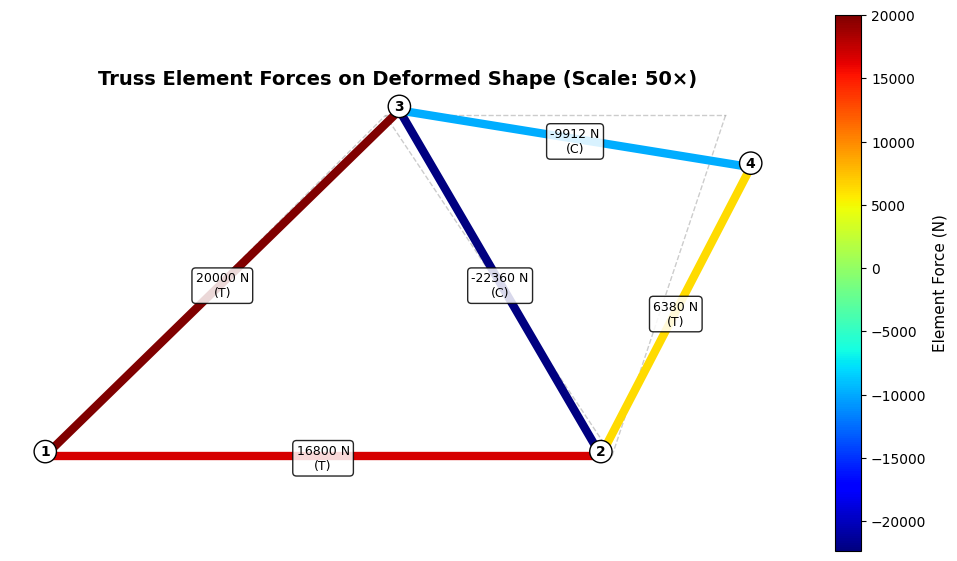

In [17]:
# | code-fold: true

from matplotlib.collections import LineCollection

# Scale factor for visualization
scale = 50

# Calculate deformed node positions
P_deformed = mk.OneArray(P + scale * U)

# Create figure
fig, ax = plt.subplots(figsize=(10, 7))

# Draw original (undeformed) truss in gray for reference
for iel in mesh.element_numbers():
    node_nums, coords = mesh.get_element(iel)
    ax.plot(coords[:, 0], coords[:, 1], 'k--', linewidth=1, alpha=0.2)

# Collect element segments (on deformed shape) and their force values
segments = []
forces = []

for iel in mesh.element_numbers():
    node_nums, coords = mesh.get_element(iel)
    coords_deformed = P_deformed[node_nums]
    segments.append(coords_deformed)  # Use deformed coordinates
    forces.append(N[iel])

# Create line collection with automatic color mapping
lc = LineCollection(segments, array=np.array(forces), cmap='jet', linewidths=6)
ax.add_collection(lc)

# Add colorbar
cbar = plt.colorbar(lc, ax=ax, shrink=0.8)
cbar.set_label('Element Force (N)', fontsize=11)

# Draw and label nodes on deformed configuration
for inode in mesh.node_numbers():
    coord_deformed = P_deformed[inode]
    ax.text(coord_deformed[0], coord_deformed[1], str(inode),
            bbox=dict(boxstyle='circle', facecolor='white'),
            fontsize=10, ha='center', weight='bold')

# Label elements with force values on deformed shape
for iel in mesh.element_numbers():
    node_nums, coords = mesh.get_element(iel)
    coords_deformed = P_deformed[node_nums]
    force = N[iel]
    xm = np.mean(coords_deformed[:, 0])
    ym = np.mean(coords_deformed[:, 1])
    force_type = "T" if force >= 0 else "C"
    ax.text(xm, ym + 10, f'{force:.0f} N\n({force_type})',
            bbox=dict(boxstyle='round', facecolor='white', 
                     edgecolor='black', alpha=0.85),
            fontsize=9, ha='center', va='top')

# Set axis limits and format
ax.autoscale()
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(f'Truss Element Forces on Deformed Shape (Scale: {scale}×)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Visualizing Reaction Forces and Applied Loads

Having visualized the internal element forces, we now complete our understanding of the structural equilibrium by examining both the reaction forces at the supports and the applied external load. These forces represent the complete external force system acting on the structure: the applied loads that drive the structural response and the support reactions that resist those loads to maintain equilibrium. The reaction forces arise at nodes where displacement constraints are imposed—in our truss example, node 1 is fully constrained in both x and y directions, while node 2 is constrained in the y direction only. The finite element analysis computes these reaction forces as part of the solution, ensuring that the structure satisfies both compatibility (displacement constraints) and equilibrium (force balance).

We visualize the complete force system using colored arrows: the applied load appears in red at node 4, while reaction forces appear in green at the constrained nodes. Arrow direction and length indicate the force vector components, with positive x-components pointing right and positive y-components pointing upward, following standard Cartesian conventions. The arrow lengths scale proportionally with force magnitude, allowing immediate visual comparison of different force magnitudes. Text labels display the magnitude of each force, providing quantitative values alongside the visual representation. This comprehensive visualization reveals the complete load path—from where forces enter the system, through internal element forces, to where they ultimately resolve into support reactions at the boundary conditions.

We begin by defining the reaction force vector from the finite element analysis. The forces are organized as alternating x and y components for each node, stored in a 1D array and then reshaped into a matrix format for convenient access:

In [18]:
# | code-fold: false

# Reaction forces (in N)
# Format: [R1x, R1y, R2x, R2y, R3x, R3y, R4x, R4y]
R_values = np.array([3200, 10000, 16800, 0, 0, -10000, -20000, 0])

# Reshape into matrix format (4 nodes × 2 components)
R = R_values.reshape(-1, 2)

# Wrap in OneArray for 1-based indexing
R = mk.OneArray(R)

In [19]:
# | echo: false
display_labeled_latex("\\mathbf{R} = ", R, precision=0, show_shape=True)

<IPython.core.display.Latex object>

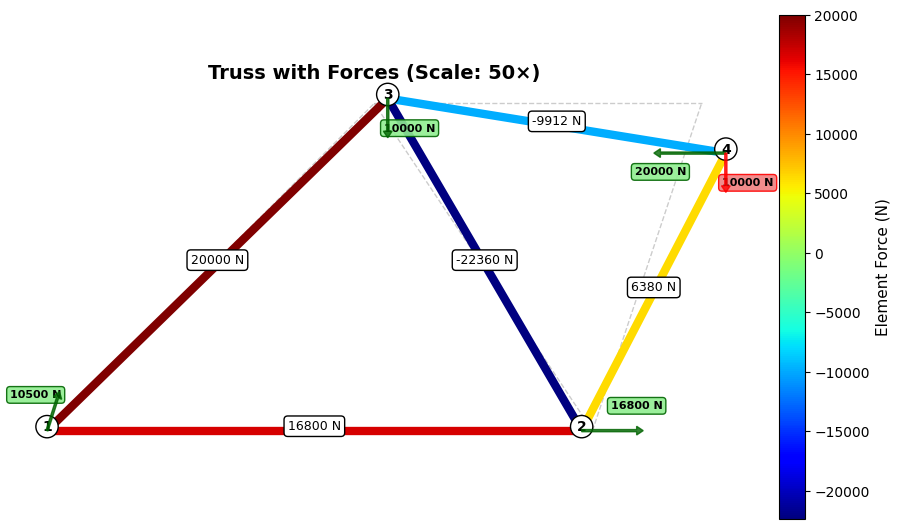

In [20]:
# | code-fold: true

from matplotlib.collections import LineCollection
from matplotlib.patches import FancyArrow

# Applied force at node 4 (in N)
F = np.array([0, -10000])

# Scale factor for visualization
scale = 50

# Calculate deformed node positions
P_deformed = mk.OneArray(P + scale * U)

# Create figure
fig, ax = plt.subplots(figsize=(10, 7))

# Draw original (undeformed) truss in gray for reference
for iel in mesh.element_numbers():
    node_nums, coords = mesh.get_element(iel)
    ax.plot(coords[:, 0], coords[:, 1], 'k--', linewidth=1, alpha=0.2)

# Collect element segments (on deformed shape) and their force values
segments = []
forces = []

for iel in mesh.element_numbers():
    node_nums, coords = mesh.get_element(iel)
    coords_deformed = P_deformed[node_nums]
    segments.append(coords_deformed)  # Use deformed coordinates
    forces.append(N[iel])

# Create line collection with automatic color mapping
lc = LineCollection(segments, array=np.array(forces), cmap='jet', linewidths=6)
ax.add_collection(lc)

# Add colorbar
cbar = plt.colorbar(lc, ax=ax, shrink=0.8)
cbar.set_label('Element Force (N)', fontsize=11)

# Draw and label nodes on deformed configuration
for inode in mesh.node_numbers():
    coord_deformed = P_deformed[inode]
    ax.text(coord_deformed[0], coord_deformed[1], str(inode),
            bbox=dict(boxstyle='circle', facecolor='white'),
            fontsize=10, ha='center', weight='bold')

# Label elements with force values on deformed shape
for iel in mesh.element_numbers():
    node_nums, coords = mesh.get_element(iel)
    coords_deformed = P_deformed[node_nums]
    force = N[iel]
    xm = np.mean(coords_deformed[:, 0])
    ym = np.mean(coords_deformed[:, 1])
    ax.text(xm, ym + 10, f'{force:.0f} N',
            bbox=dict(boxstyle='round', facecolor='white',
                     edgecolor='black'),
            fontsize=9, ha='center', va='top')

# Arrow scaling: scale arrows to reasonable visual length
# All arrows will be scaled proportionally to their magnitude
max_arrow_length = 60  # Maximum arrow length in plot units

# Find maximum force magnitude for scaling
R_magnitudes = np.linalg.norm(R.data, axis=1)
F_mag = np.linalg.norm(F)
all_magnitudes = np.append(R_magnitudes, F_mag)
max_force = max(all_magnitudes)

# Scaling factor: scale largest force to max_arrow_length
arrow_scale_factor = max_arrow_length / max_force

# Draw reaction force arrows with magnitude-based scaling
for inode in mesh.node_numbers():
    coord_deformed = P_deformed[inode]
    Rx = R[inode][0]  # x-component of reaction
    Ry = R[inode][1]  # y-component of reaction

    # Only draw arrows for non-zero reaction components
    if abs(Rx) > 1e-6 or abs(Ry) > 1e-6:
        # Scale arrow components
        Rx_scaled = Rx * arrow_scale_factor
        Ry_scaled = Ry * arrow_scale_factor
        
        # Draw arrow using FancyArrow
        arrow = FancyArrow(coord_deformed[0], coord_deformed[1],
                          Rx_scaled, Ry_scaled,
                          width=2, head_width=8, head_length=6,
                          fc='darkgreen', ec='darkgreen', alpha=0.8, zorder=5)
        ax.add_patch(arrow)

        # Add text labels for reaction force magnitude
        R_mag = np.sqrt(Rx**2 + Ry**2)
        label_offset = 20

        # Position label at the arrow tip
        label_x = coord_deformed[0] + Rx_scaled
        label_y = coord_deformed[1] + Ry_scaled

        # Offset label perpendicular to arrow direction
        if abs(Ry) > abs(Rx):
            label_x += label_offset if Ry < 0 else -label_offset
        else:
            label_y += label_offset if Rx > 0 else -label_offset

        ax.text(label_x, label_y, f'{R_mag:.0f} N',
               bbox=dict(boxstyle='round', facecolor='lightgreen',
                        edgecolor='darkgreen', alpha=0.9),
               fontsize=8, ha='center', weight='bold')

# Draw applied force arrow at node 4 in red
node4_coord = P_deformed[4]
F_scaled = F * arrow_scale_factor

arrow_F = FancyArrow(node4_coord[0], node4_coord[1],
                     F_scaled[0], F_scaled[1],
                     width=2, head_width=8, head_length=6,
                     fc='red', ec='red', alpha=0.8, zorder=5)
ax.add_patch(arrow_F)

# Add label for applied force
F_mag = np.sqrt(F[0]**2 + F[1]**2)
label_x = node4_coord[0] + F_scaled[0] + 20
label_y = node4_coord[1] + F_scaled[1]
ax.text(label_x, label_y, f'{F_mag:.0f} N',
       bbox=dict(boxstyle='round', facecolor='lightcoral',
                edgecolor='red', alpha=0.9),
       fontsize=8, ha='center', weight='bold')

# Set axis limits and format
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(f'Truss with Forces (Scale: {scale}×)',
             fontsize=14, fontweight='bold')

# Adjust layout manually to avoid tight_layout warning
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)
plt.show()

In [21]:
# | echo: false
display_labeled_latex("\\mathbf{R} = ", R, precision=0, show_shape=True)

<IPython.core.display.Latex object>

### Code Explanation

This code creates a comprehensive visualization showing element forces, reaction forces, and applied loads on the deformed truss. Here's a detailed breakdown of each section:

#### 1. Initial Setup and Imports

```python
from matplotlib.collections import LineCollection
from matplotlib.patches import FancyArrow

F = np.array([0, -10000])
scale = 50
P_deformed = mk.OneArray(P + scale * U)
```

- **`LineCollection`**: Used for efficiently drawing the color-coded element force lines
- **`FancyArrow`**: Provides better control over arrow appearance compared to `quiver`
- **`F`**: Applied force vector at node 4 (Fx = 0 N, Fy = -10000 N pointing downward)
- **`scale`**: Magnifies displacements by 50× for visibility
- **`P_deformed`**: Deformed node positions wrapped in `OneArray` for 1-based indexing

#### 2. Drawing Base Structure

```python
# Draw original (undeformed) truss in gray
for iel in mesh.element_numbers():
    node_nums, coords = mesh.get_element(iel)
    ax.plot(coords[:, 0], coords[:, 1], 'k--', linewidth=1, alpha=0.2)

# Collect element segments and forces
segments = []
forces = []
for iel in mesh.element_numbers():
    node_nums, coords = mesh.get_element(iel)
    coords_deformed = P_deformed[node_nums]
    segments.append(coords_deformed)
    forces.append(N[iel])
```

- **First loop**: Draws undeformed truss as gray dashed reference (`'k--'`, `alpha=0.2`)
- **Second loop**: Collects deformed element coordinates and corresponding force values
- **`segments`**: List of element coordinate pairs on deformed shape
- **`forces`**: List of axial forces for each element (from `N` array)

#### 3. Color-Coded Element Forces

```python
lc = LineCollection(segments, array=np.array(forces), cmap='jet', linewidths=6)
ax.add_collection(lc)

cbar = plt.colorbar(lc, ax=ax, shrink=0.8)
cbar.set_label('Element Force (N)', fontsize=11)
```

- **`LineCollection`**: Creates collection of line segments with automatic color mapping
- **`array=forces`**: Maps force values to colors using the colormap
- **`cmap='jet'`**: Color scheme (blue → cyan → green → yellow → red)
- **`linewidths=6`**: Thick lines for visibility
- **`colorbar`**: Adds legend showing force-to-color mapping

#### 4. Node and Element Labels

```python
# Label nodes
for inode in mesh.node_numbers():
    coord_deformed = P_deformed[inode]
    ax.text(coord_deformed[0], coord_deformed[1], str(inode),
            bbox=dict(boxstyle='circle', facecolor='white'),
            fontsize=10, ha='center', weight='bold')

# Label elements
for iel in mesh.element_numbers():
    node_nums, coords = mesh.get_element(iel)
    coords_deformed = P_deformed[node_nums]
    force = N[iel]
    xm = np.mean(coords_deformed[:, 0])
    ym = np.mean(coords_deformed[:, 1])
    ax.text(xm, ym + 10, f'{force:.0f} N',
            bbox=dict(boxstyle='round', facecolor='white'),
            fontsize=9, ha='center', va='top')
```

- **Node labels**: Display node numbers at deformed positions with white circular background
- **Element labels**: Show force magnitude at element midpoints
- **`{force:.0f} N`**: Format force to 0 decimal places with units
- **`va='top'`**: Vertical alignment places text above the reference point

#### 5. Arrow Scaling Setup

```python
max_arrow_length = 60  # Maximum arrow length in plot units

# Compute force magnitudes
R_magnitudes = np.linalg.norm(R.data, axis=1)  # Row-wise norm of reactions
F_mag = np.linalg.norm(F)                       # Magnitude of applied force
all_magnitudes = np.append(R_magnitudes, F_mag)
max_force = max(all_magnitudes)

# Scaling factor
arrow_scale_factor = max_arrow_length / max_force
```

- **`max_arrow_length`**: Target length (in plot units) for the largest force arrow
- **`R.data`**: Accesses underlying numpy array from `OneArray` wrapper
- **`axis=1`**: Computes norm along rows → one magnitude per node
- **`all_magnitudes`**: Combined array of all reaction + applied force magnitudes
- **`arrow_scale_factor`**: Converts force magnitude to arrow length proportionally
- **Scaling ensures**: Largest force = 60 units, others scale proportionally

#### 6. Drawing Reaction Force Arrows

```python
for inode in mesh.node_numbers():
    coord_deformed = P_deformed[inode]
    Rx = R[inode][0]  # x-component
    Ry = R[inode][1]  # y-component

    if abs(Rx) > 1e-6 or abs(Ry) > 1e-6:
        # Scale components
        Rx_scaled = Rx * arrow_scale_factor
        Ry_scaled = Ry * arrow_scale_factor
        
        # Draw arrow
        arrow = FancyArrow(coord_deformed[0], coord_deformed[1],
                          Rx_scaled, Ry_scaled,
                          width=2, head_width=8, head_length=6,
                          fc='darkgreen', ec='darkgreen', alpha=0.8, zorder=5)
        ax.add_patch(arrow)
```

- **`R[inode][0]`**: Access x-component using 1-based indexing (via `OneArray`)
- **`R[inode][1]`**: Access y-component
- **Threshold check**: Only draw arrows for non-zero forces (`> 1e-6`)
- **`FancyArrow`**: Creates arrow starting at `(x, y)` with displacement `(dx, dy)`
- **`width=2`**: Arrow shaft width in data coordinates
- **`head_width=8`**, **`head_length=6`**: Arrowhead dimensions
- **`fc`**, **`ec`**: Fill and edge colors (both dark green for reactions)
- **`zorder=5`**: Draw arrows on top of other elements

#### 7. Reaction Force Labels

```python
        R_mag = np.sqrt(Rx**2 + Ry**2)
        label_offset = 20

        # Position label at arrow tip
        label_x = coord_deformed[0] + Rx_scaled
        label_y = coord_deformed[1] + Ry_scaled

        # Offset perpendicular to arrow
        if abs(Ry) > abs(Rx):
            label_x += label_offset if Ry < 0 else -label_offset
        else:
            label_y += label_offset if Rx > 0 else -label_offset

        ax.text(label_x, label_y, f'{R_mag:.0f} N',
               bbox=dict(boxstyle='round', facecolor='lightgreen'),
               fontsize=8, ha='center', weight='bold')
```

- **`R_mag`**: Compute reaction force magnitude from components
- **Base position**: Start at arrow tip `(coord + scaled_force)`
- **Perpendicular offset logic**:
  - If mostly vertical (`|Ry| > |Rx|`): offset horizontally
  - If mostly horizontal: offset vertically
  - Direction depends on arrow direction to avoid overlap
- **Label formatting**: Shows magnitude with green background matching arrow color

#### 8. Drawing Applied Force Arrow

```python
node4_coord = P_deformed[4]
F_scaled = F * arrow_scale_factor

arrow_F = FancyArrow(node4_coord[0], node4_coord[1],
                     F_scaled[0], F_scaled[1],
                     width=2, head_width=8, head_length=6,
                     fc='red', ec='red', alpha=0.8, zorder=5)
ax.add_patch(arrow_F)

# Label
F_mag = np.sqrt(F[0]**2 + F[1]**2)
label_x = node4_coord[0] + F_scaled[0] + 20
label_y = node4_coord[1] + F_scaled[1]
ax.text(label_x, label_y, f'{F_mag:.0f} N',
       bbox=dict(boxstyle='round', facecolor='lightcoral'),
       fontsize=8, ha='center', weight='bold')
```

- **`node4_coord`**: Get deformed position of node 4 using 1-based indexing
- **`F_scaled`**: Scale both components of applied force vector
- **Arrow color**: Red (`fc='red'`, `ec='red'`) distinguishes from reactions
- **Arrow properties**: Same dimensions as reaction arrows for consistency
- **Label**: Red/coral background matching arrow, positioned at arrow tip + offset

#### 9. Final Formatting

```python
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(f'Truss with Forces (Scale: {scale}×)',
             fontsize=14, fontweight='bold')
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)
plt.show()
```

- **`set_aspect('equal')`**: Ensures x and y scales are identical (no distortion)
- **`axis('off')`**: Hides axis ticks and labels for cleaner presentation
- **`set_title`**: Adds descriptive title showing deformation scale factor
- **`subplots_adjust`**: Manually sets margins (avoids `tight_layout` warning)
- **Margin values**: `left`, `right`, `top`, `bottom` as fractions of figure size

## Simplified Visualization with MechanicsKit.patch

We have been building visualizations manually using matplotlib's `LineCollection` and iterating through elements. While this provides full control, it requires substantial code for what is fundamentally a common operation in FEM visualization: drawing a mesh with color-coded data. MechanicsKit provides the `patch()` function, which mimics MATLAB's patch functionality and dramatically simplifies mesh visualization with automatic handling of indexing, color mapping, and interpolation.

The `patch()` function accepts Faces/Vertices notation with natural 1-based indexing and automatically handles the conversion, color mapping, and collection creation. We demonstrate its use by recreating our displacement magnitude visualization with significantly less code.

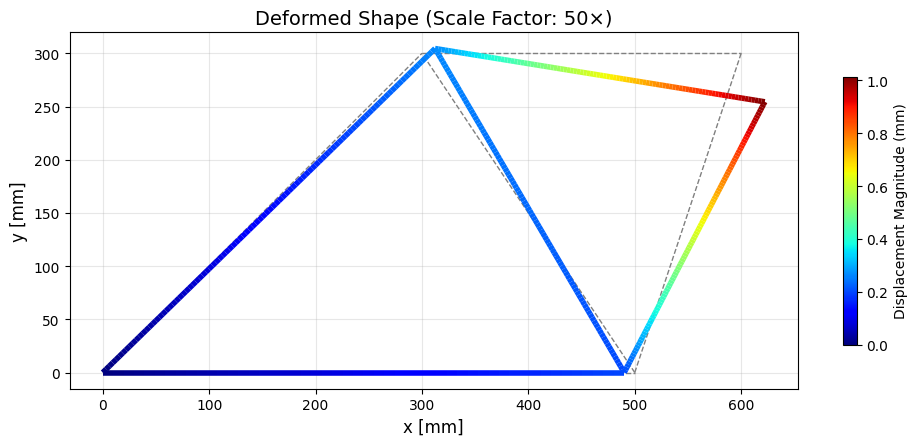

In [22]:
# | code-fold: true
import mechanicskit as mk

# Scale factor for visualization
scale = 50

# Calculate deformed node positions
P_deformed = P + scale * U

# Compute displacement magnitudes at each node
U_res = np.sqrt(U[:, 0]**2 + U[:, 1]**2)

# Create figure
fig, ax = plt.subplots(figsize=(10, 7))

# Draw undeformed truss in gray
mk.patch('Faces', edges, 'Vertices', P,
         'EdgeColor', 'gray', 'LineWidth', 1, 'LineStyle', '--')

# Draw deformed truss with interpolated displacement colors
mk.patch('Faces', edges, 'Vertices', P_deformed,
         'FaceVertexCData', U_res,
         'FaceColor', 'interp',
         'LineWidth', 4,
         'cmap', 'jet')

mk.cmap('jet', label="Displacement Magnitude (mm)", shrink=0.4)



ax.set_xlabel("x [mm]", fontsize=12)
ax.set_ylabel("y [mm]", fontsize=12)
ax.set_title(f"Deformed Shape (Scale Factor: {scale}×)", fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

### Understanding the Simplification

Compare the `patch()` approach to our previous manual implementation. The manual approach required approximately 50 lines of code with explicit loops, segment creation, and color interpolation. The `patch()` function reduces this to a single call:

```python
mk.patch('Faces', edges, 'Vertices', P_deformed,
         'FaceVertexCData', U_res,
         'FaceColor', 'interp',
         'LineWidth', 4,
         'cmap', 'jet')
```

This single line accomplishes several tasks automatically:

`'Faces'`, `edges`:

* `'Faces'` is a keyword indicating that the next argument provides the element connectivity.
* `edges` is a NumPy array defining how the nodes are connected to form elements. In this case, since the elements are 2-node connections (like in a truss), mk.patch interprets these as line elements. The values in edges are assumed to be 1-based node numbers (as is common in FEM), which mk.patch internally converts to 0-based for Matplotlib.

`'Vertices'`, `P_deformed`:

* `'Vertices'` is a keyword indicating that the next argument provides the coordinates of the nodes.
* `P_deformed` is a NumPy array containing the (x, y) coordinates of each node in the mesh, possibly representing the deformed state of the structure (e.g., original coordinates P plus scaled nodal displacements U).

`'FaceVertexCData'`, `U_res`:

* `'FaceVertexCData'` is a keyword for the "color data" that will be mapped to the elements.
* `U_res` is a NumPy array containing scalar values (e.g., resultant nodal displacements, temperatures, stresses) associated with either the nodes or the elements. Since FaceColor is set to 'interp', U_res is
         interpreted as per-node data.

`'FaceColor'`, `'interp'`:

* `'FaceColor'` specifies how the FaceVertexCData should be used to color the elements.
* `'interp'` (interpolated) mode is crucial here. For line elements (truss members), this tells mk.patch to create a smooth color gradient along each element. The color at any point along a truss member will be
         interpolated from the U_res values of its two connecting nodes.

`'cmap'`, `'jet'`:

* `'cmap'` specifies the colormap to use for converting the scalar FaceVertexCData values into actual visual colors.
* `'jet'` is a commonly used Matplotlib colormap, often characterized by a spectrum from blue (low values) through green and yellow to red (high values). Comparible to many commercial FEM software.



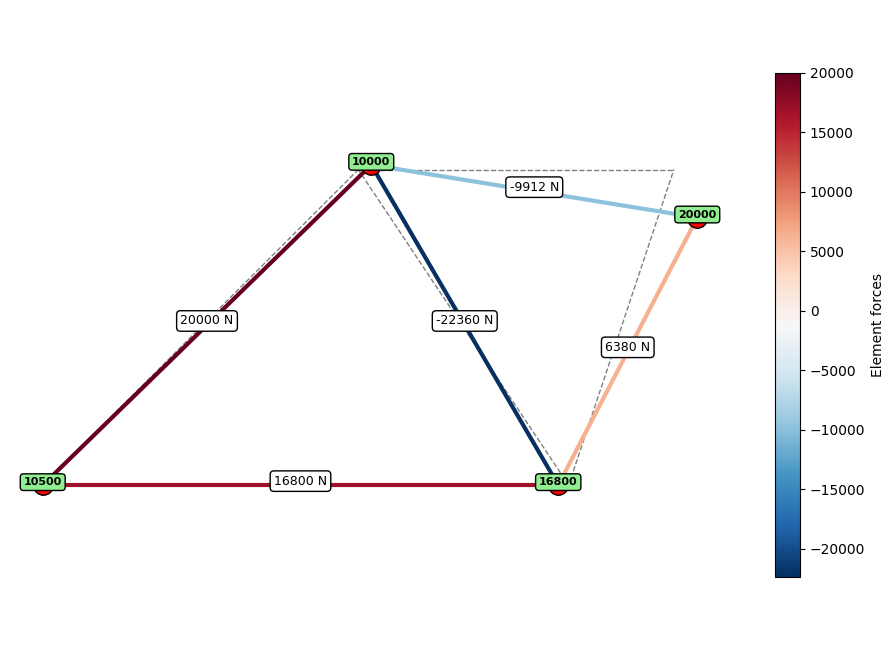

In [23]:
# | code-fold: true

from matplotlib.collections import LineCollection
from matplotlib.patches import FancyArrow

# Applied force at node 4 (in N)
F = np.array([0, -10000])

# Reaction forces (in N)
# Format: [R1x, R1y, R2x, R2y, R3x, R3y, R4x, R4y]
R_values = np.array([3200, 10000, 16800, 0, 0, -10000, -20000, 0])

# Scale factor for visualization
scale = 50

R = R_values.reshape(-1, 2) # Reshape into matrix format (4 nodes × 2 components)
R = mk.OneArray(R) # Wrap in OneArray for 1-based indexing

# Calculate deformed node positions
P_deformed = mk.OneArray(P + scale * U)

# Create figure
fig, ax = plt.subplots(figsize=(10, 7))

# Draw original (undeformed) truss in gray for reference
mk.patch('Faces', edges, 'Vertices', P,
         'EdgeColor', 'gray', 'LineWidth', 1, 'LineStyle', '--')


mk.patch('Faces', edges, 'Vertices', P_deformed.data,
         'FaceVertexCData', forces,
         'FaceColor', 'flat',
         'LineWidth', 3,
         'cmap', 'RdBu_r')  # Red for tension, blue for compression

mk.cmap('RdBu_r', label="Element forces", shrink=0.8)


ax.plot(P_deformed.data[:,0], P_deformed.data[:,1], 'o', color='red',
        markeredgecolor='black', markersize=14)


for iel, inods, coords in mesh.iter_elements():
    coords_deformed = P_deformed[inods]
    force = N[iel]
    xm = np.mean(coords_deformed[:, 0])
    ym = np.mean(coords_deformed[:, 1])
    ax.text(xm, ym + 10, f'{force:.0f} N',
            bbox=dict(boxstyle='round', facecolor='white',
                     edgecolor='black'),
            fontsize=9, ha='center', va='top')


R_magnitudes = np.linalg.norm(R.data, axis=1)
R_magnitudes = mk.OneArray(R_magnitudes)

for inod, coords in mesh.iter_nodes():
        coord_deformed = P_deformed[inod]
        ax.text(coord_deformed[0], coord_deformed[1], f'{R_magnitudes[inod]:.0f}',
                bbox=dict(boxstyle='round', facecolor='lightgreen'),
                fontsize=8, ha='center', weight='bold')

ax.axis('equal')
ax.axis('off')
ax.set_title('')


# # Adjust layout manually to avoid tight_layout warning
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)

## More examnples

More example are available in the MechanicsKit repository:

- [Patch examples](https://github.com/cenmir/MechanicsKit/blob/main/examples/notebooks/examples_patch.ipynb)
- [OneArray](https://github.com/cenmir/MechanicsKit/blob/main/examples/notebooks/examples_mesh_onearray.ipynb)

See also the example in [Systematic Truss Analysis](SystematicTrussAnalysis.ipynb) for a complete truss analysis workflow using MechanicsKit.